# SMOTE — Synthesizing Minority Examples Instead of Copying Them

Random oversampling fixes the class ratio by duplicating minority points. The ratio is right
afterwards, but no new information has been added: a flexible model can memorize the handful of
distinct locations, and the minority decision region ends up drawn tightly around them.

**SMOTE** — Synthetic Minority Over-sampling Technique — makes up new points instead. Each synthetic
example is placed on the line segment between a real minority point and one of its minority
neighbours, filling in the region those points occupy rather than stacking copies on top of them.

## Learning objectives

- Explain how SMOTE interpolates new minority samples along neighbour segments
- Apply `imblearn.over_sampling.SMOTE` to a training split
- Compare the resampled scatter against the original to see what was synthesized
- Choose `k_neighbors` sensibly, and say what goes wrong when it is too large or too small
- Compare SMOTE's effect on decision regions against plain oversampling

## Background

This notebook assumes random oversampling and its duplication problem from
`U1-7_Imbalance-2_Resampling`, the classification metrics from `U1-6_Classify-3_F1Score`, and the
decision-region plots from `U1-6_Classify-1_CompareRegions`. It uses the same `GenerateData` clouds
at the same 10:1 ratio, so results are directly comparable.

**Prerequisites:** `U1-7_Imbalance-2_Resampling` (oversampling and its limits)

**Dataset:** none — two 2-D Gaussian clouds from `GenerateData`, at a 1000:100 (10:1) ratio.

**References:** https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Tools: entropy, region painting, and the data generator

Three helpers carried across the imbalance notebooks.

`GenerateData(n_pts0, n_pts1, center_sep, std)` draws two 2-D Gaussian clouds with a controllable
**imbalance ratio** — the two counts are independent, so a 10:1 or 4:1 split is one argument away —
and a controllable **overlap** via `center_sep` and `std`. Imbalance and overlap are separate
problems and this lets us vary them separately.

`entropy` and `visualize_regions` are the decision-region tools from
`U1-6_Classify-1_CompareRegions`: predict on a dense grid, reshape into an image, and return both
the predicted class and the entropy of the predicted probabilities at each point.

In [2]:
import math

def entropy( x, b ):
    s = 0
    for p in x:
        if p > 0:
            s += -p*math.log(p,b)
        # end
    # end
    return s
# end

def visualize_regions(model, MAX, nGrid):
    a1 = np.linspace(-MAX, MAX, nGrid)
    a2 = np.linspace(-MAX, MAX, nGrid)

    A1, A2 = np.meshgrid(a1, a2)
    A1 = A1.flatten()
    A2 = A2.flatten()
    A = np.vstack((A1, A2)).T

    # Predict B
    B = model.predict(A)
    B = B.reshape(nGrid, nGrid)
    B = np.flipud(B)

    # Compute entropy for S
    prob_2D = model.predict_proba(A)
    S = np.array([entropy(p, 2) for p in prob_2D])
    S = S.reshape(nGrid, nGrid)
    S = np.flipud(S)

    return B, S
# end
    
def GenerateData(n_pts1,n_pts2,center_sep,std):
    
    cov = std**2*np.eye(2)
    
    x1 = np.random.multivariate_normal(mean=[-center_sep/2,0],
                                       cov=cov,
                                       size=n_pts1)
    y1 = np.zeros(n_pts1)
    
    x2 = np.random.multivariate_normal(mean=[center_sep/2,0],
                                       cov=cov,
                                       size=n_pts2)
    y2 = np.ones(n_pts2)
    
    X = np.concatenate((x1,x2),axis=0)
    y = np.concatenate((y1,y2),axis=0).astype(int)
    
    return X, y
# end

## 2. Create the data

The same 10:1 clouds as `U1-7_Imbalance-2_Resampling`, so the two notebooks can be read against each
other.

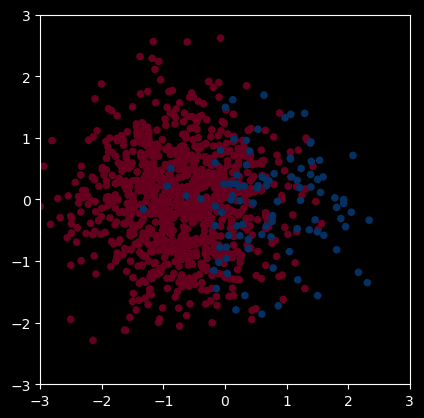

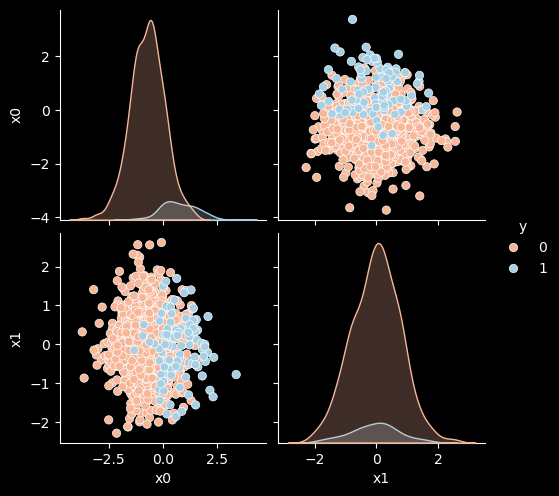

In [3]:
#np.random.seed(0)

n_pts0     = 1000
n_pts1     = 100
std        = 0.8
center_sep = 1.5

# generate data
X, y = GenerateData(
    n_pts0,
    n_pts1,
    center_sep,
    std
)

MAX = np.max(np.abs(X))

cmap = 'RdBu'

plt_scale = 3
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap=cmap)
plt.xlim(-plt_scale,plt_scale)
plt.ylim(-plt_scale,plt_scale)
plt.gca().set_aspect('equal')
plt.show()

df = pd.DataFrame( {"x0":X[:,0], "x1":X[:,1], "y":y} )
sns.pairplot(df, hue='y', palette='RdBu')
plt.show()

## 3. Applying SMOTE

For each minority point $\mathbf{x}_i$, SMOTE picks one of its $k$ nearest **minority** neighbours
$\mathbf{x}_{zi}$ and places a new point at a random spot on the segment between them:

$$\mathbf{x}_{\text{new}} = \mathbf{x}_i + \lambda\,(\mathbf{x}_{zi} - \mathbf{x}_i),
\qquad \lambda \sim \mathcal{U}(0, 1)$$

So every synthetic point is a convex combination of two real ones. This fills in the interior of the
minority cloud rather than piling duplicates onto existing coordinates — which is the entire
difference from `RandomOverSampler`.

`k_neighbors` controls how far a synthetic point can be placed from its parent, and both extremes
misbehave:

- **Too small** (say 1) — new points cling to the nearest neighbour, and SMOTE behaves much like
  plain duplication.
- **Too large** — parents get paired with distant minority points, and the interpolated point can
  land in a region that belongs to the majority class, manufacturing mislabeled data.

It must also be smaller than the number of minority samples, or there are not enough neighbours to
draw from. Here `k_neighbors=20` against ~80 minority training points.

Two standing caveats. SMOTE interpolates in feature space, so it assumes the space is meaningful —
distances must mean something, which implies scaling first, and it does not respect categorical or
integer-valued features (`SMOTENC` exists for that). And, as always, it is applied **only to the
training split**; the test set keeps the real ratio.

In [4]:
#!pip install imbalanced-learn

In [5]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

In [6]:
smote = SMOTE(
    sampling_strategy='auto',
    k_neighbors=20,
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Original data:")
print(pd.Series(y).value_counts())
print()
print("Training data:")
print(pd.Series(y_train_res).value_counts())
print()
print("Testing data:")
print(pd.Series(y_test).value_counts())

Original data:
0    1000
1     100
Name: count, dtype: int64

Training data:
0    800
1    800
Name: count, dtype: int64

Testing data:
0    200
1     20
Name: count, dtype: int64


### 3.1 What was synthesized

Original training data on the left, SMOTE-resampled on the right, same axes.

Look at where the new minority points are. They fill the *interior* and the segments between
existing minority points — no point appears outside the convex hull of the original minority cloud,
because every synthetic point is a convex combination of two real ones. That is also SMOTE's
limitation: it can only densify the region the minority class already occupies, never discover that
the class extends somewhere unsampled.

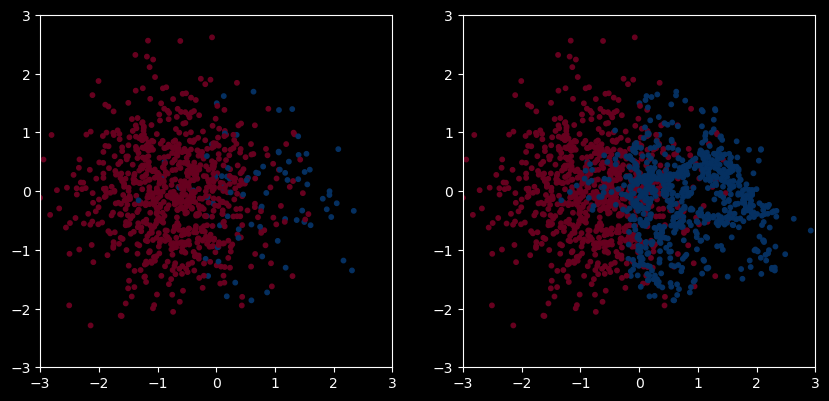

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap)
axes[0].set_xlim(-plt_scale,plt_scale)
axes[0].set_ylim(-plt_scale,plt_scale)
axes[0].set_aspect('equal')

axes[1].scatter(X_train_res[:,0], X_train_res[:,1], c=y_train_res, s=10, cmap=cmap)
axes[1].set_xlim(-plt_scale,plt_scale)
axes[1].set_ylim(-plt_scale,plt_scale)
axes[1].set_aspect('equal')

plt.show()

## 4. Does it help the models?

Each model is fit twice — on the original imbalanced training set and on the SMOTE-resampled one —
and both are scored on the same untouched test set.

Compare the two confusion matrices per model, focusing on minority recall. Then compare the decision
regions: SMOTE should push the boundary outward to enclose more of the minority cloud, and the
enclosed region should look smoother and better-supported than plain duplication would give, since
the synthetic points spread through the region rather than stacking at a few coordinates.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = [
    LogisticRegression(),
    KNeighborsClassifier(n_neighbors=1,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=5,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=10,  weights='uniform'),
    KNeighborsClassifier(n_neighbors=50,  weights='uniform'),
    RandomForestClassifier(n_estimators=10,  max_leaf_nodes=3),
    RandomForestClassifier(n_estimators=10,  max_leaf_nodes=10),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30),
    GradientBoostingClassifier(n_estimators=10,  learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=10,  learning_rate=0.1, max_leaf_nodes=10),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
]

LogisticRegression()
Original dataset:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       200
           1       0.67      0.30      0.41        20

    accuracy                           0.92       220
   macro avg       0.80      0.64      0.69       220
weighted avg       0.91      0.92      0.91       220



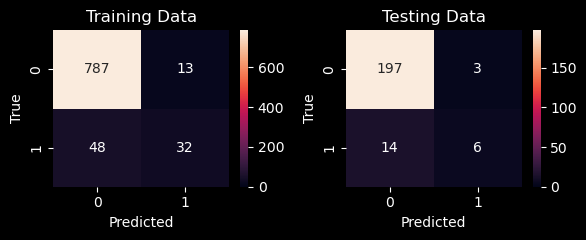

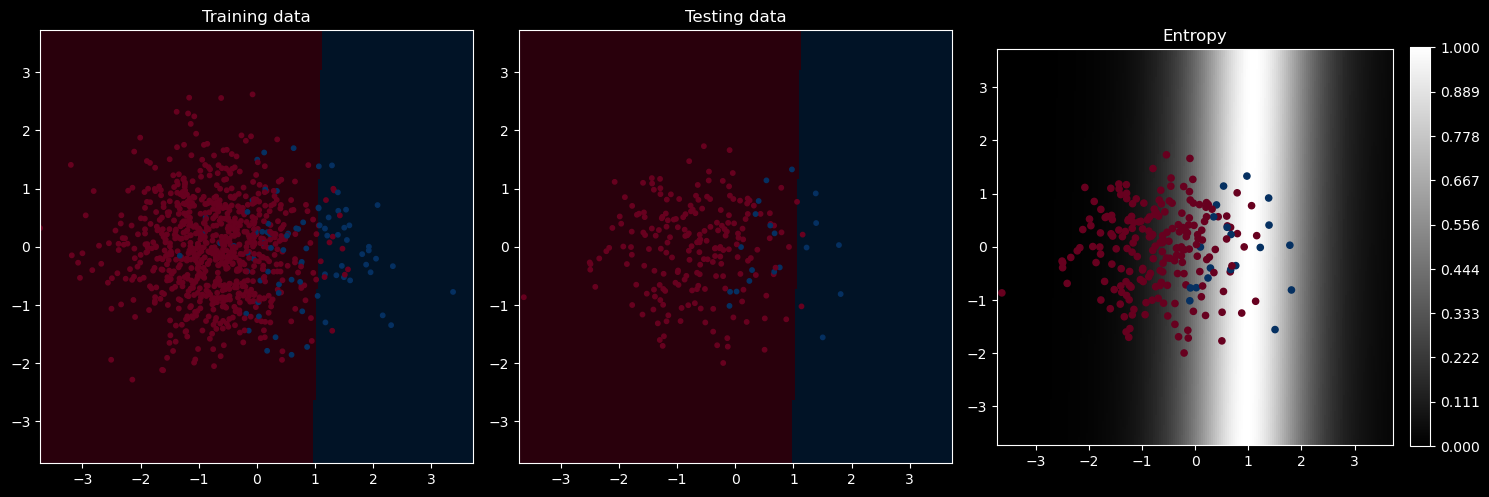

Resampled dataset:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89       200
           1       0.32      0.90      0.47        20

    accuracy                           0.82       220
   macro avg       0.65      0.85      0.68       220
weighted avg       0.93      0.82      0.85       220



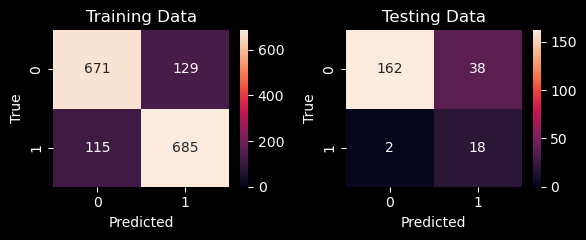

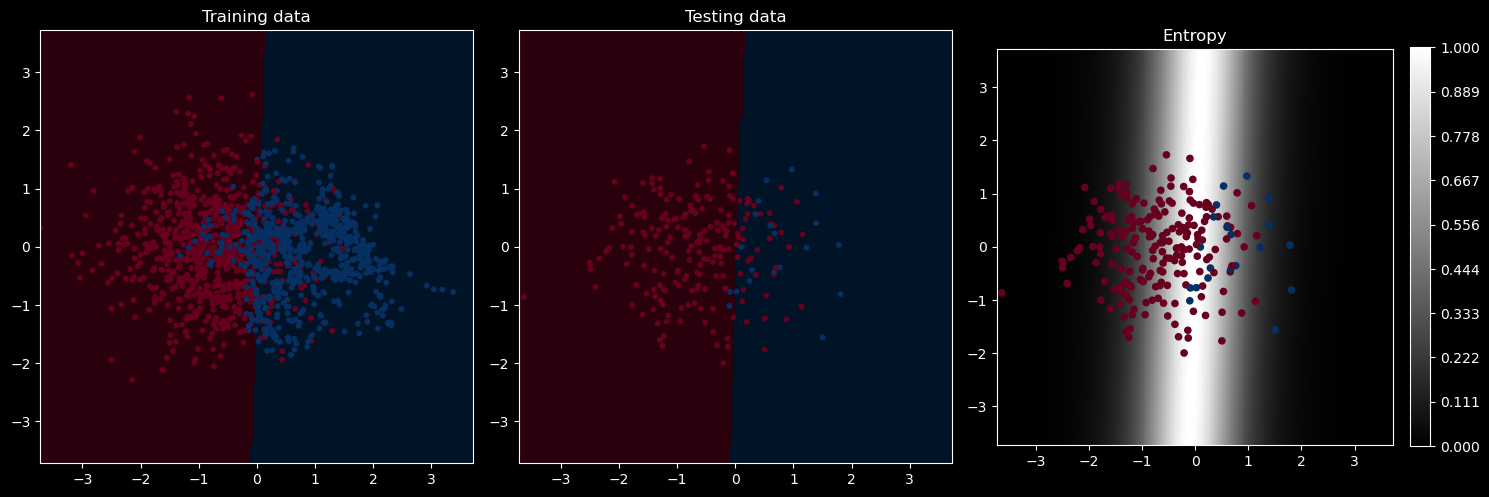




KNeighborsClassifier(n_neighbors=1)
Original dataset:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       200
           1       0.36      0.25      0.29        20

    accuracy                           0.89       220
   macro avg       0.64      0.60      0.62       220
weighted avg       0.88      0.89      0.88       220



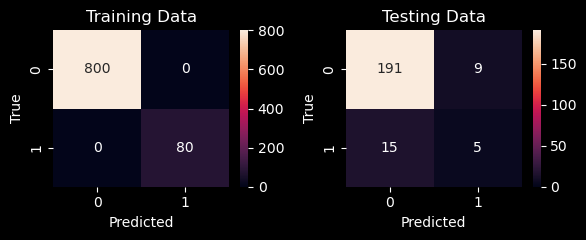

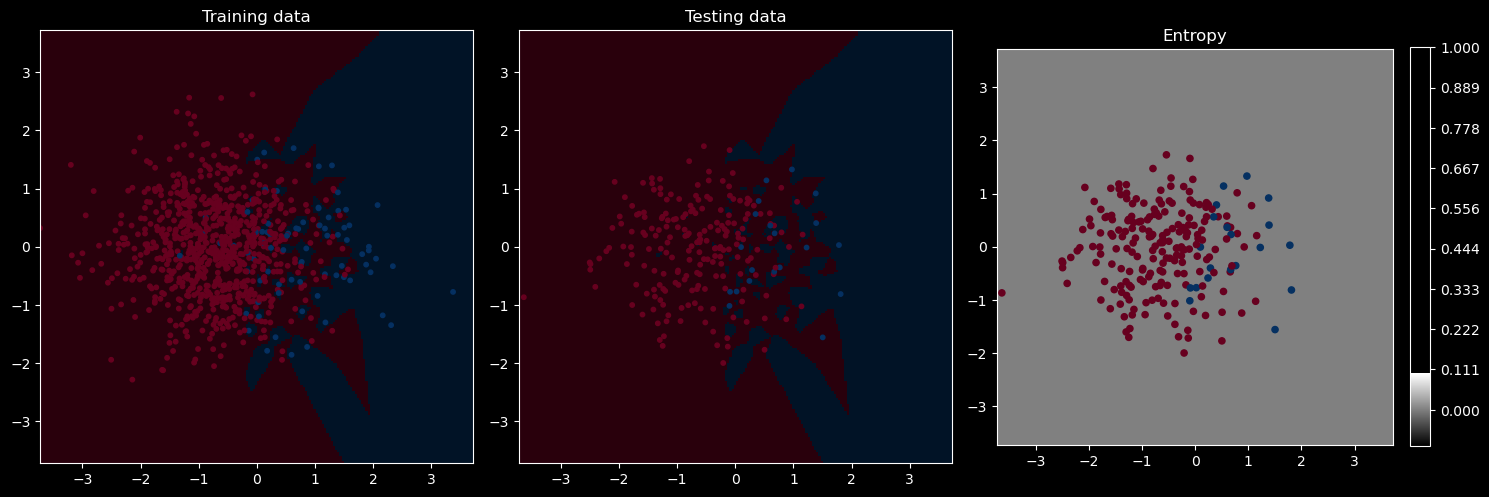

Resampled dataset:
              precision    recall  f1-score   support

           0       0.97      0.78      0.86       200
           1       0.25      0.75      0.38        20

    accuracy                           0.78       220
   macro avg       0.61      0.77      0.62       220
weighted avg       0.90      0.78      0.82       220



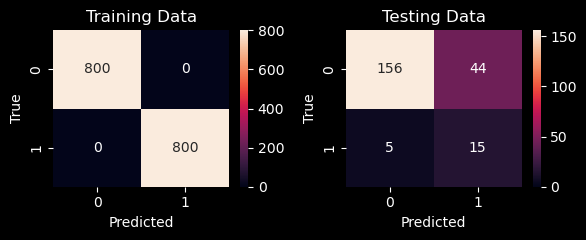

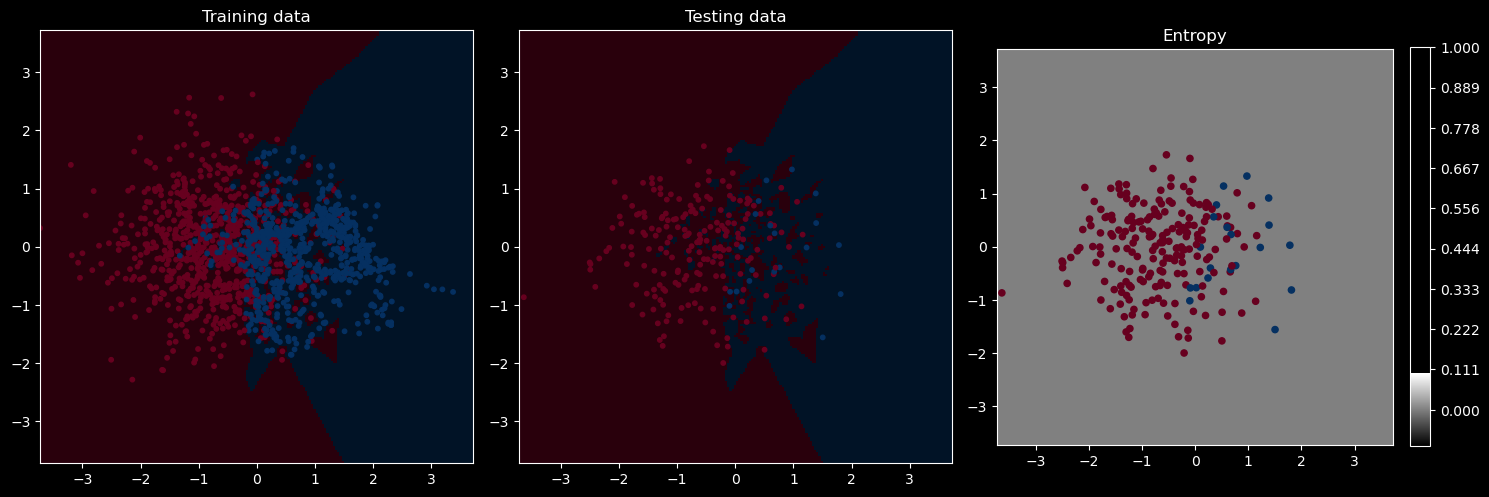




KNeighborsClassifier()
Original dataset:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       200
           1       0.45      0.25      0.32        20

    accuracy                           0.90       220
   macro avg       0.69      0.61      0.64       220
weighted avg       0.89      0.90      0.89       220



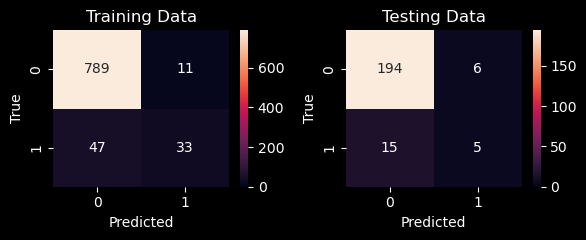

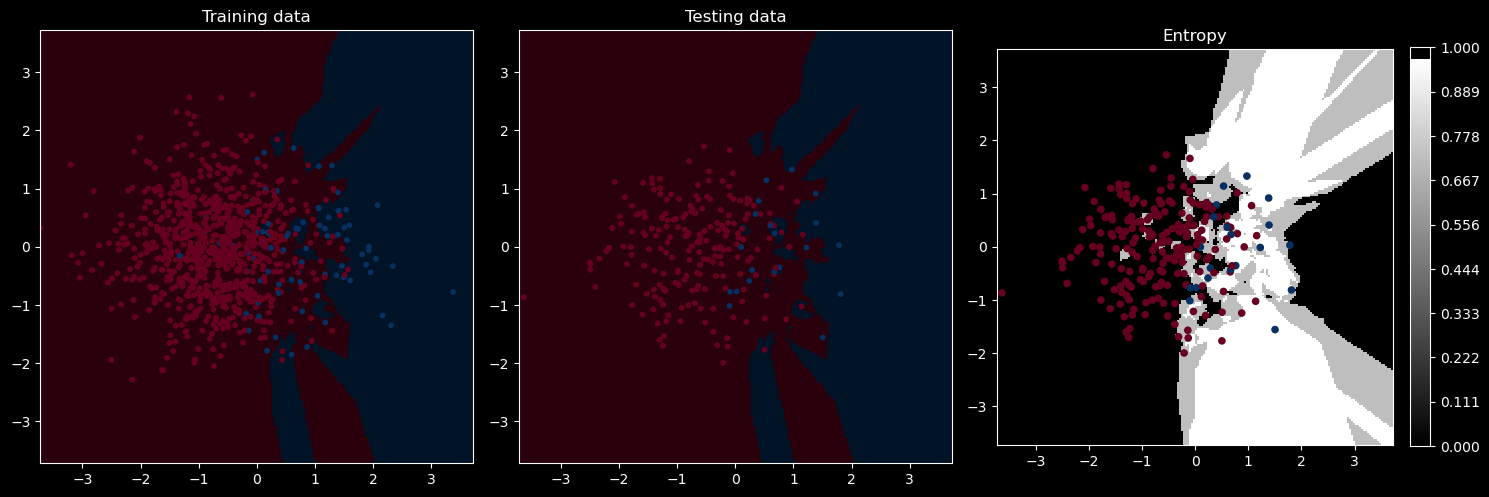

Resampled dataset:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89       200
           1       0.30      0.80      0.43        20

    accuracy                           0.81       220
   macro avg       0.64      0.81      0.66       220
weighted avg       0.91      0.81      0.84       220



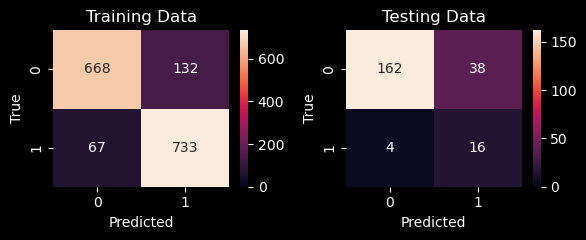

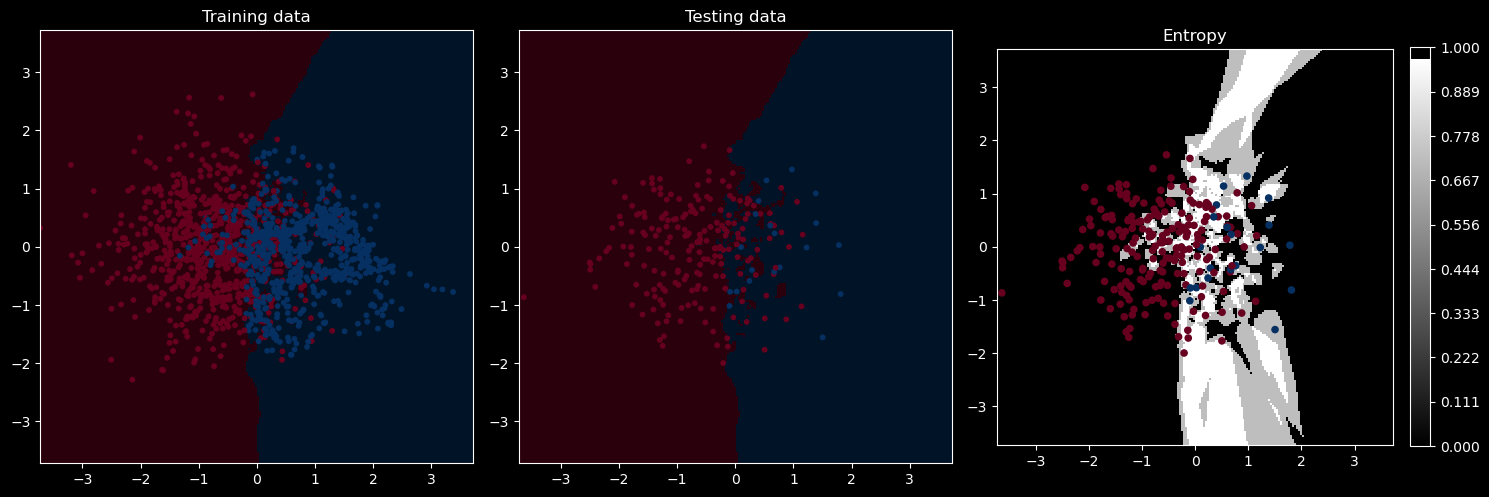




KNeighborsClassifier(n_neighbors=10)
Original dataset:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       200
           1       1.00      0.25      0.40        20

    accuracy                           0.93       220
   macro avg       0.97      0.62      0.68       220
weighted avg       0.94      0.93      0.91       220



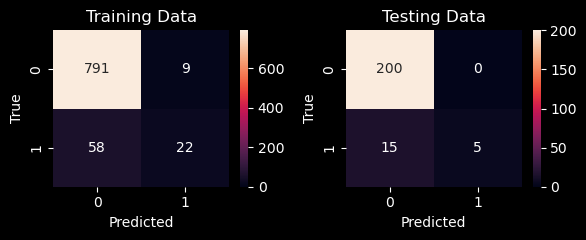

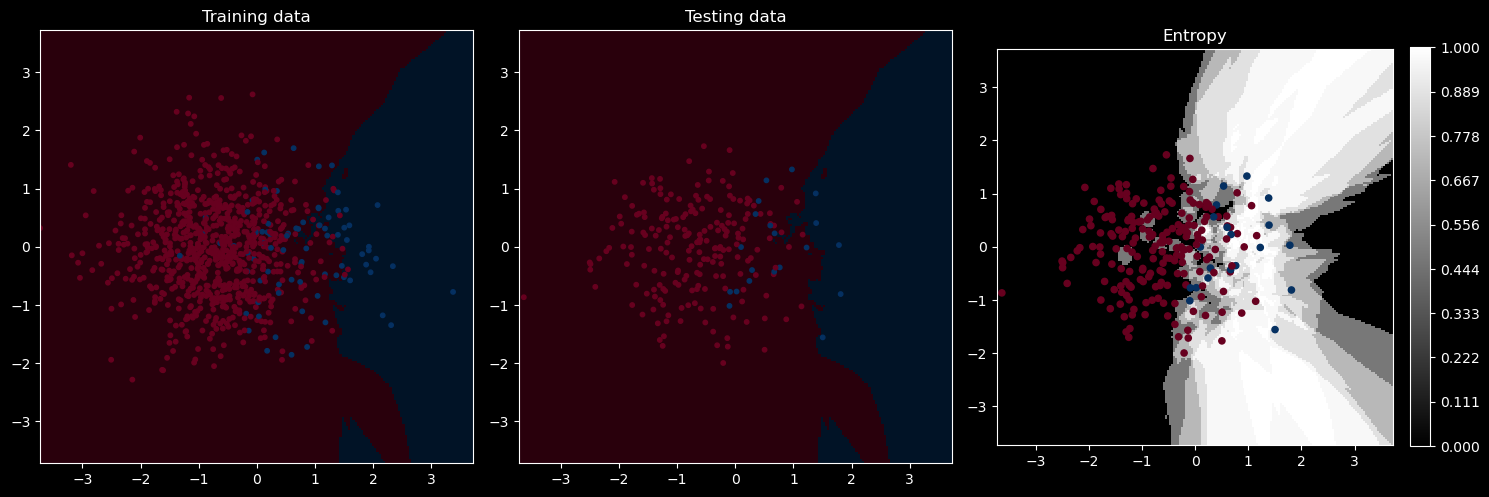

Resampled dataset:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90       200
           1       0.31      0.75      0.44        20

    accuracy                           0.83       220
   macro avg       0.64      0.79      0.67       220
weighted avg       0.91      0.83      0.86       220



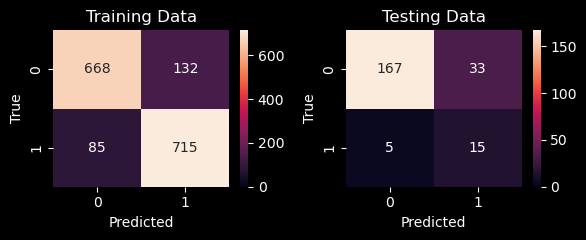

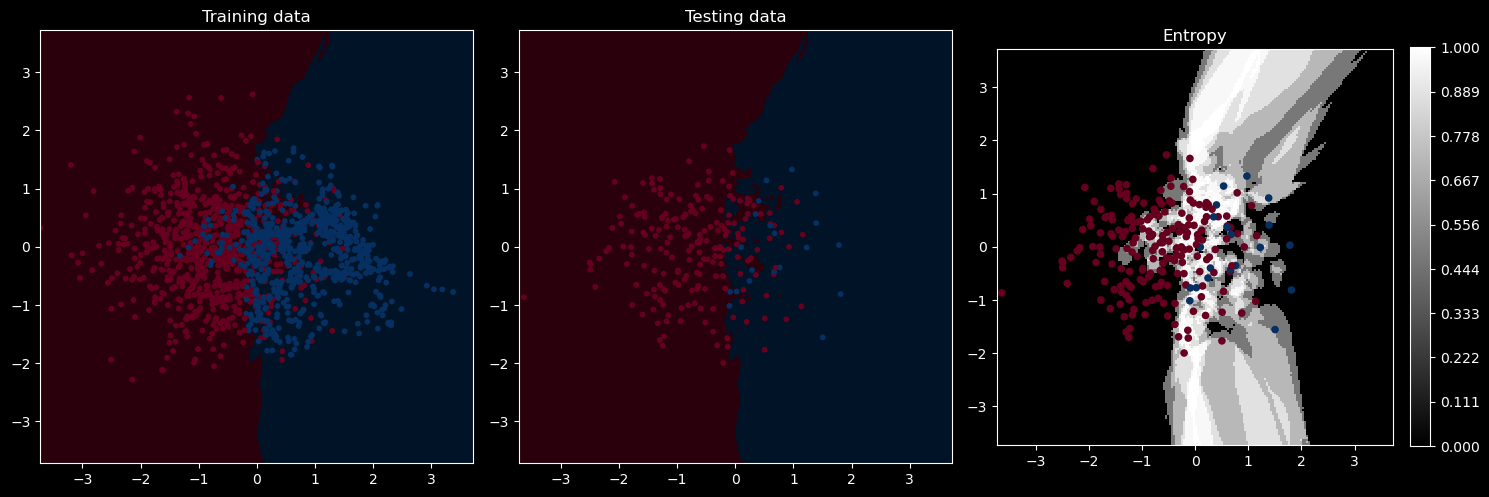




KNeighborsClassifier(n_neighbors=50)
Original dataset:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       200
           1       1.00      0.20      0.33        20

    accuracy                           0.93       220
   macro avg       0.96      0.60      0.65       220
weighted avg       0.93      0.93      0.90       220



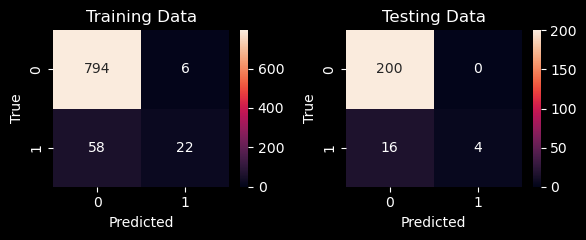

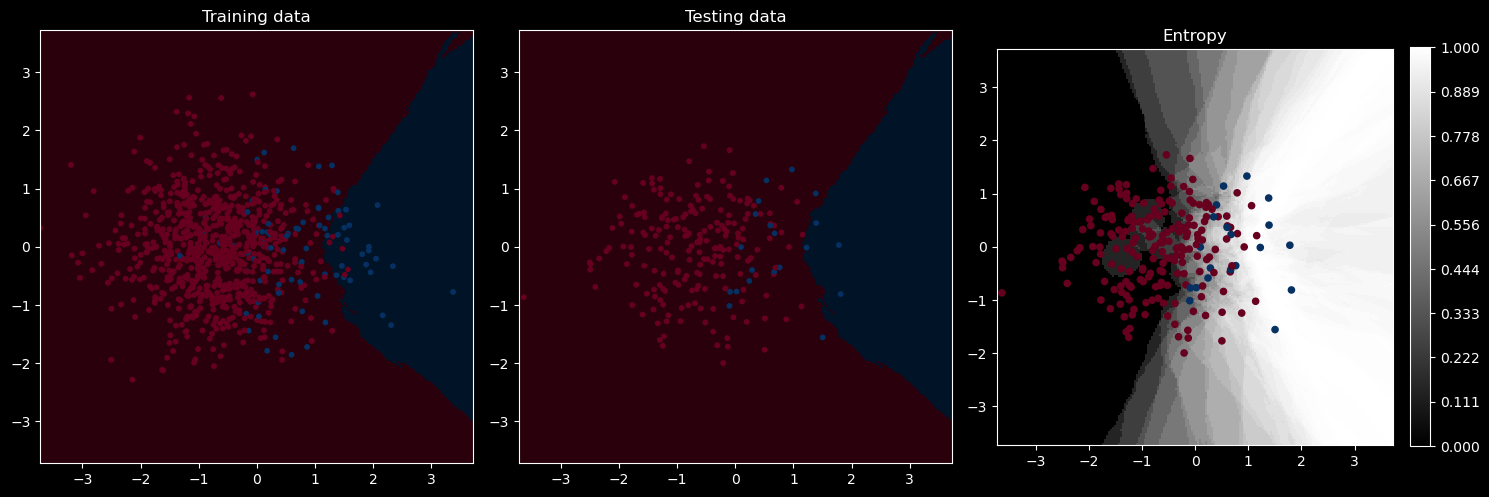

Resampled dataset:
              precision    recall  f1-score   support

           0       0.99      0.78      0.87       200
           1       0.29      0.90      0.44        20

    accuracy                           0.79       220
   macro avg       0.64      0.84      0.66       220
weighted avg       0.92      0.79      0.83       220



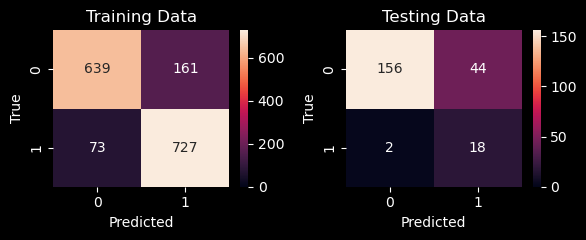

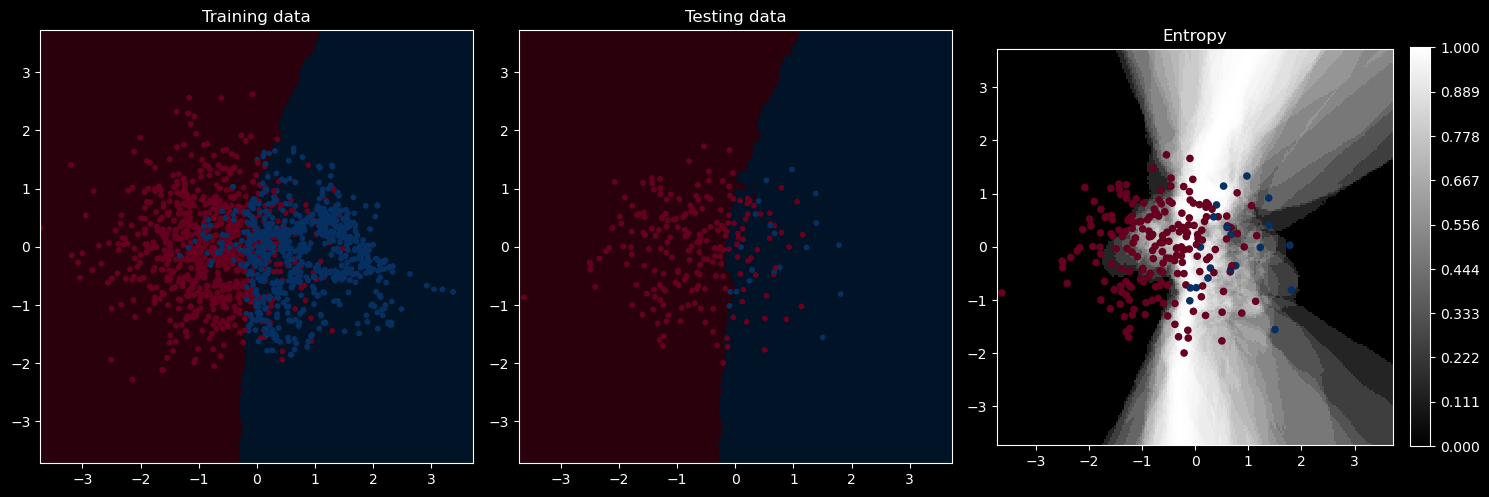




RandomForestClassifier(max_leaf_nodes=3, n_estimators=10)
Original dataset:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       200
           1       1.00      0.05      0.10        20

    accuracy                           0.91       220
   macro avg       0.96      0.53      0.52       220
weighted avg       0.92      0.91      0.88       220



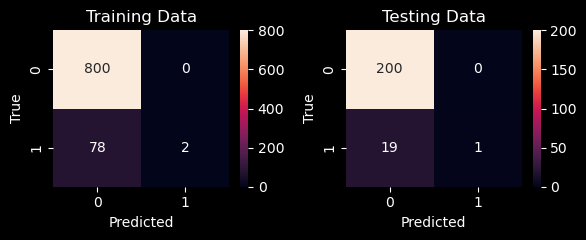

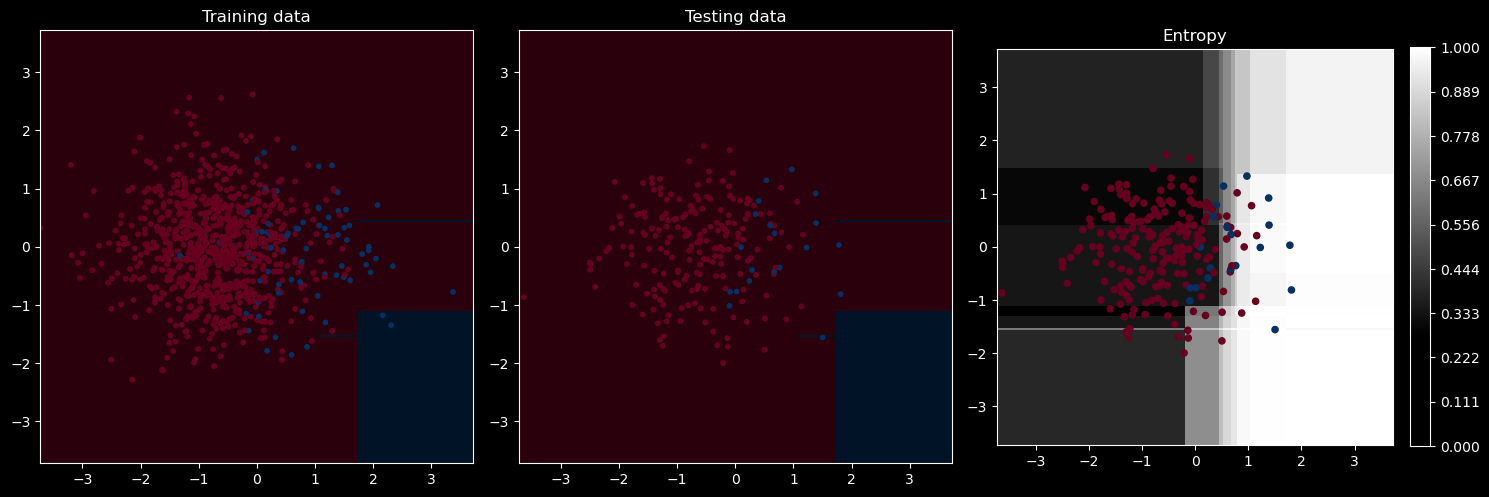

Resampled dataset:
              precision    recall  f1-score   support

           0       1.00      0.73      0.85       200
           1       0.27      1.00      0.43        20

    accuracy                           0.76       220
   macro avg       0.64      0.87      0.64       220
weighted avg       0.93      0.76      0.81       220



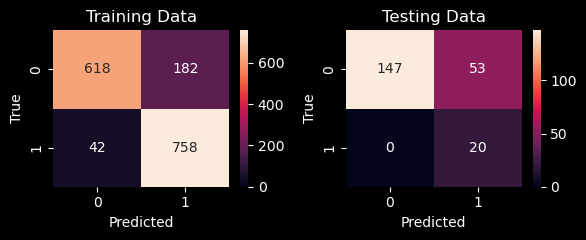

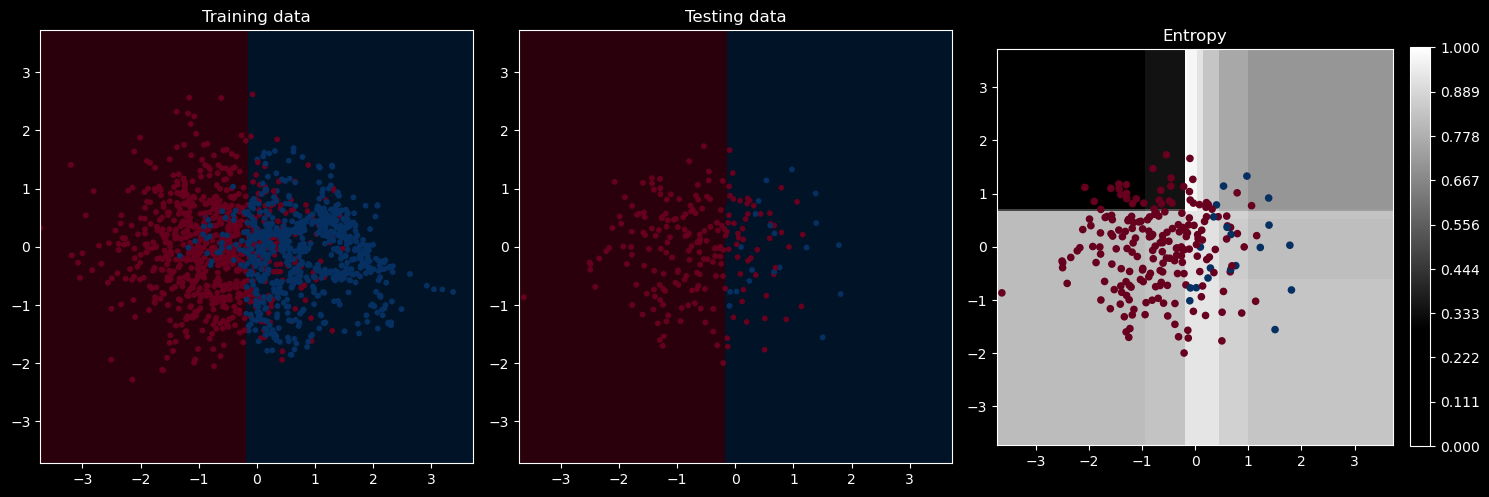




RandomForestClassifier(max_leaf_nodes=10, n_estimators=10)
Original dataset:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       200
           1       0.86      0.30      0.44        20

    accuracy                           0.93       220
   macro avg       0.90      0.65      0.70       220
weighted avg       0.93      0.93      0.92       220



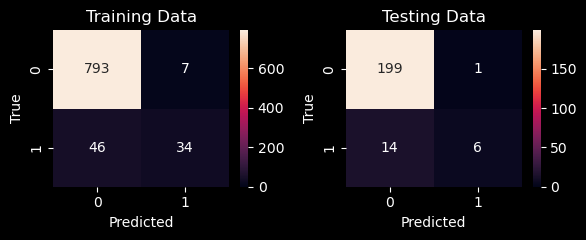

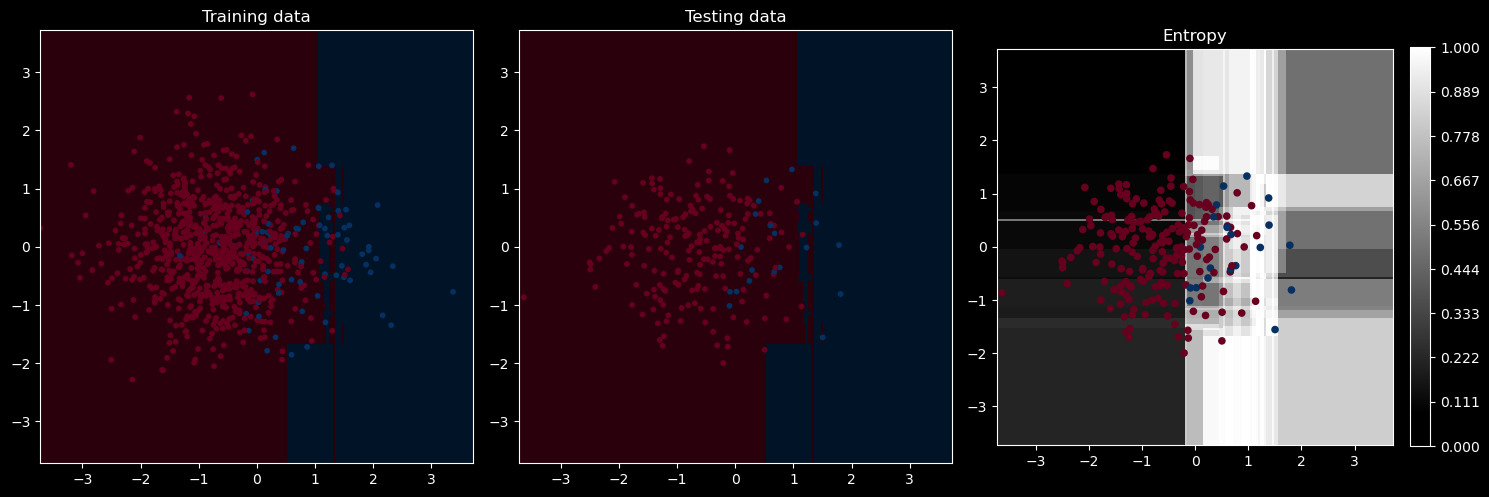

Resampled dataset:
              precision    recall  f1-score   support

           0       1.00      0.75      0.86       200
           1       0.29      1.00      0.44        20

    accuracy                           0.77       220
   macro avg       0.64      0.88      0.65       220
weighted avg       0.94      0.77      0.82       220



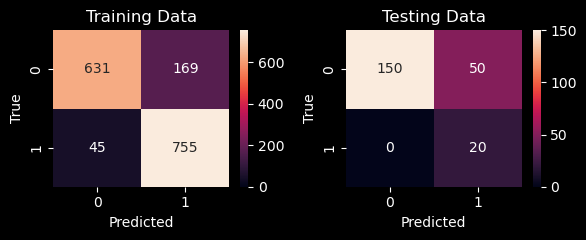

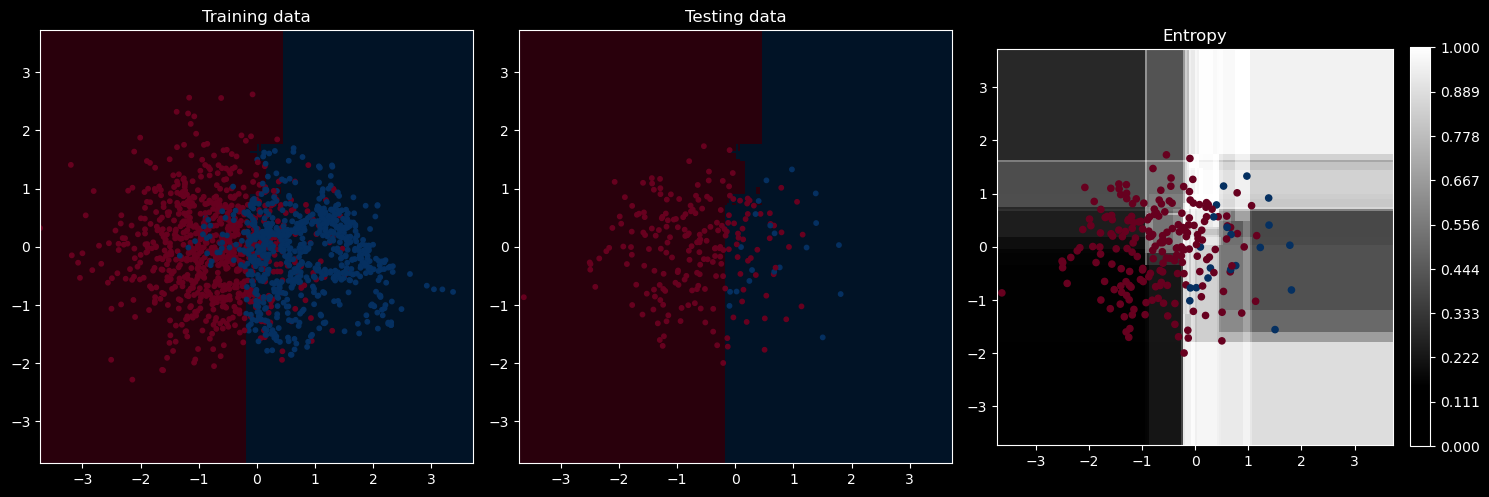




RandomForestClassifier(max_leaf_nodes=3)
Original dataset:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       200
           1       1.00      0.25      0.40        20

    accuracy                           0.93       220
   macro avg       0.97      0.62      0.68       220
weighted avg       0.94      0.93      0.91       220



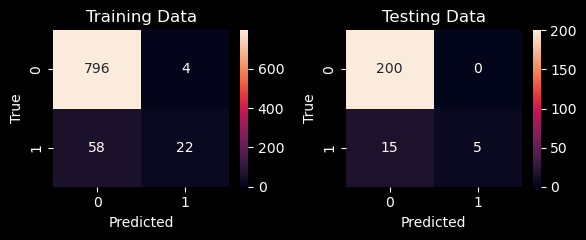

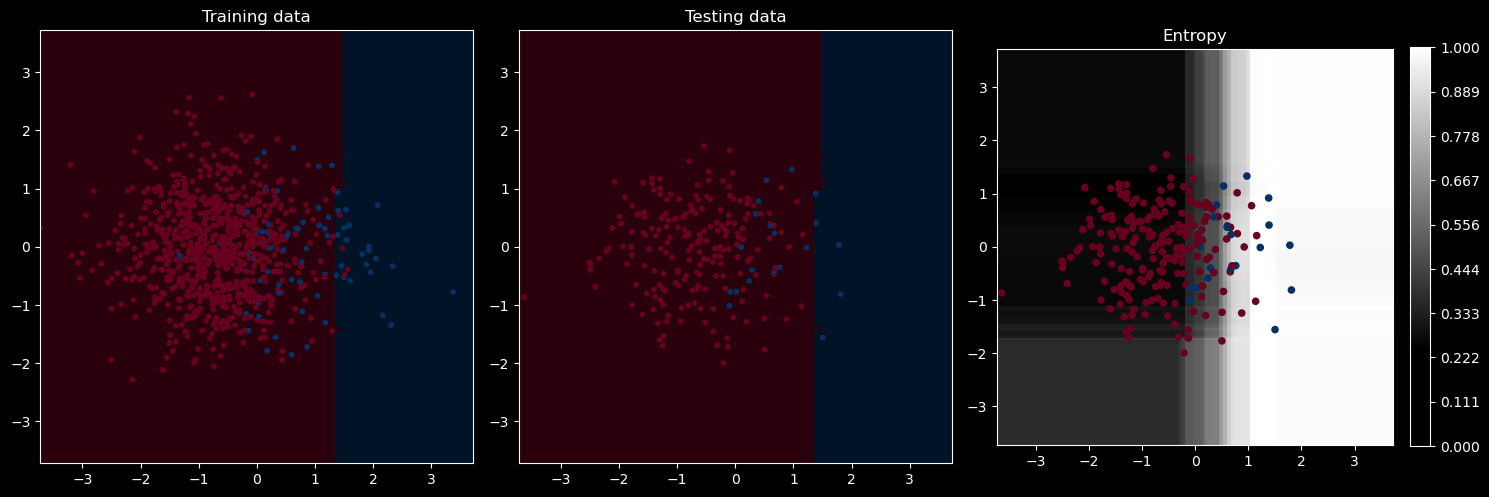

Resampled dataset:
              precision    recall  f1-score   support

           0       1.00      0.77      0.87       200
           1       0.30      1.00      0.46        20

    accuracy                           0.79       220
   macro avg       0.65      0.88      0.66       220
weighted avg       0.94      0.79      0.83       220



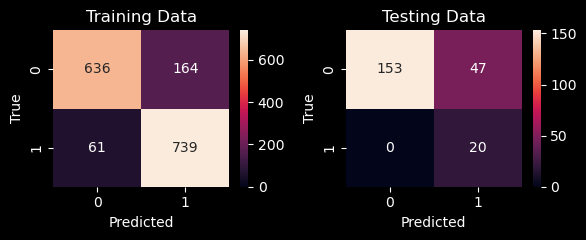

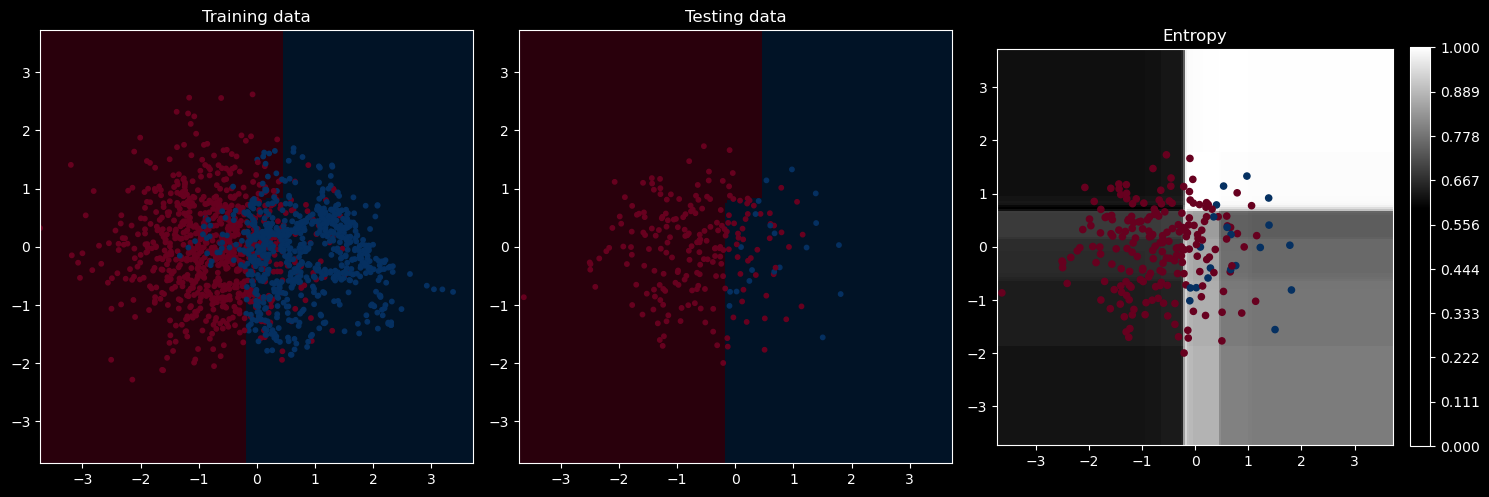




RandomForestClassifier(max_leaf_nodes=10)
Original dataset:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       200
           1       0.86      0.30      0.44        20

    accuracy                           0.93       220
   macro avg       0.90      0.65      0.70       220
weighted avg       0.93      0.93      0.92       220



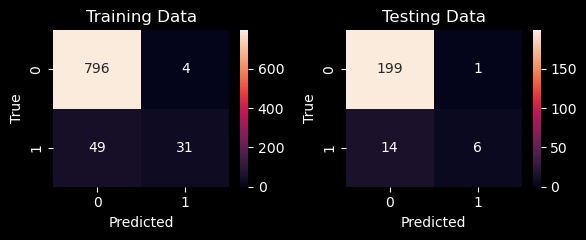

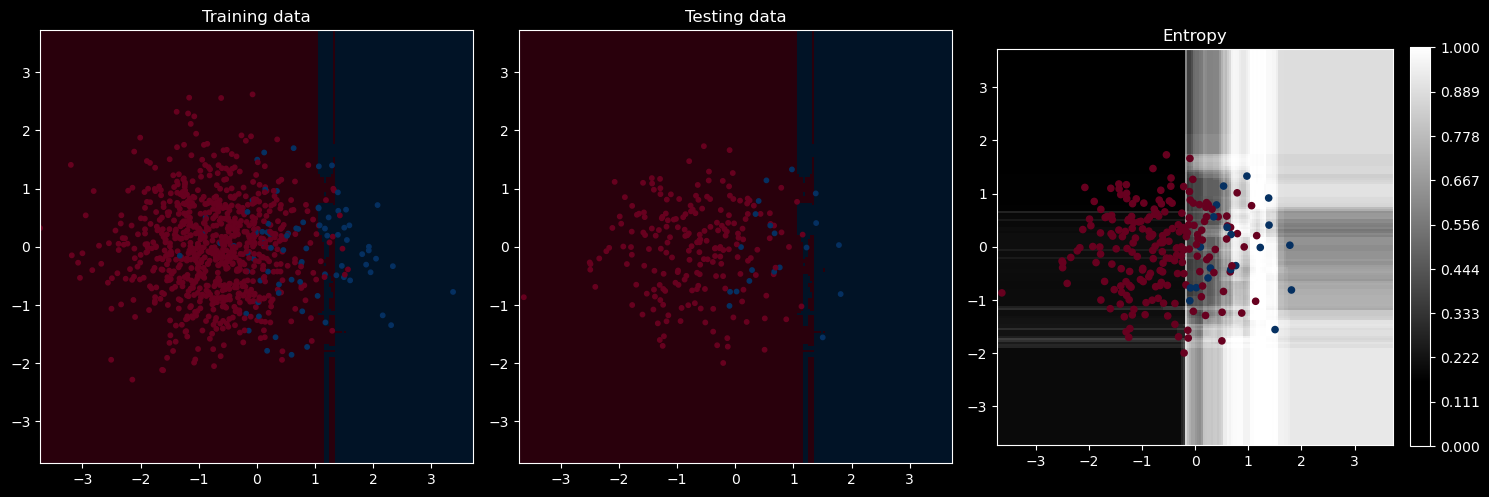

Resampled dataset:
              precision    recall  f1-score   support

           0       0.99      0.77      0.86       200
           1       0.29      0.95      0.44        20

    accuracy                           0.78       220
   macro avg       0.64      0.86      0.65       220
weighted avg       0.93      0.78      0.83       220



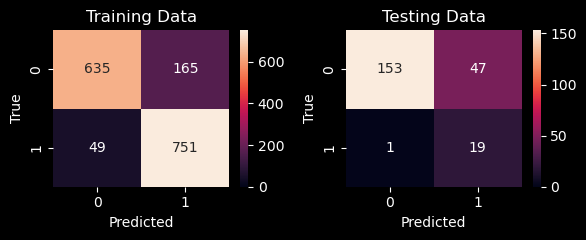

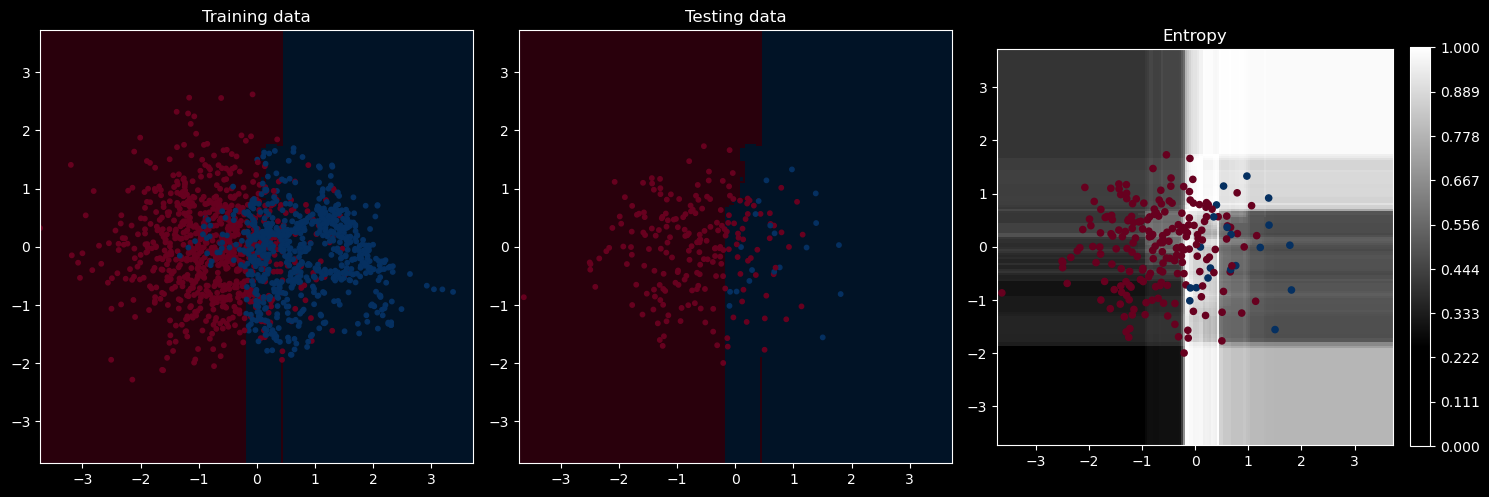




RandomForestClassifier(max_leaf_nodes=30)
Original dataset:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       200
           1       0.62      0.25      0.36        20

    accuracy                           0.92       220
   macro avg       0.78      0.62      0.66       220
weighted avg       0.90      0.92      0.90       220



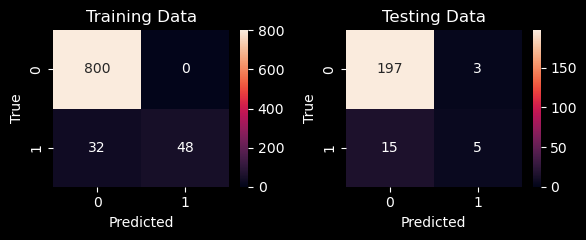

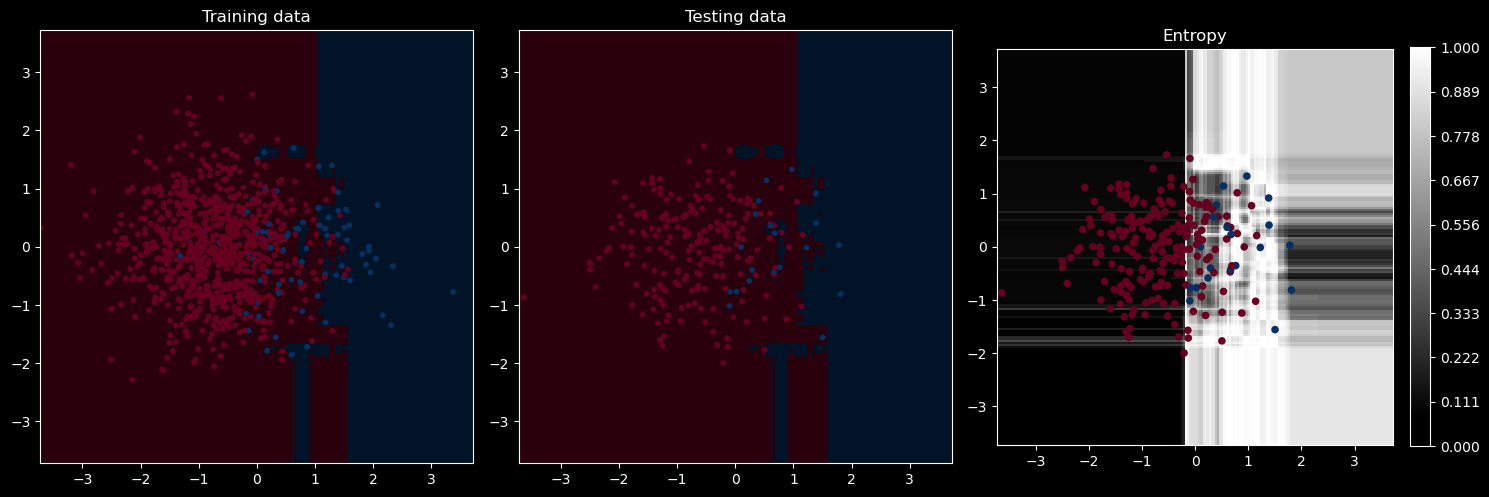

Resampled dataset:


              precision    recall  f1-score   support

           0       0.99      0.77      0.87       200
           1       0.29      0.95      0.45        20

    accuracy                           0.79       220
   macro avg       0.64      0.86      0.66       220
weighted avg       0.93      0.79      0.83       220



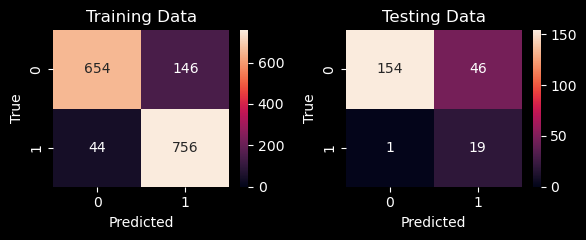

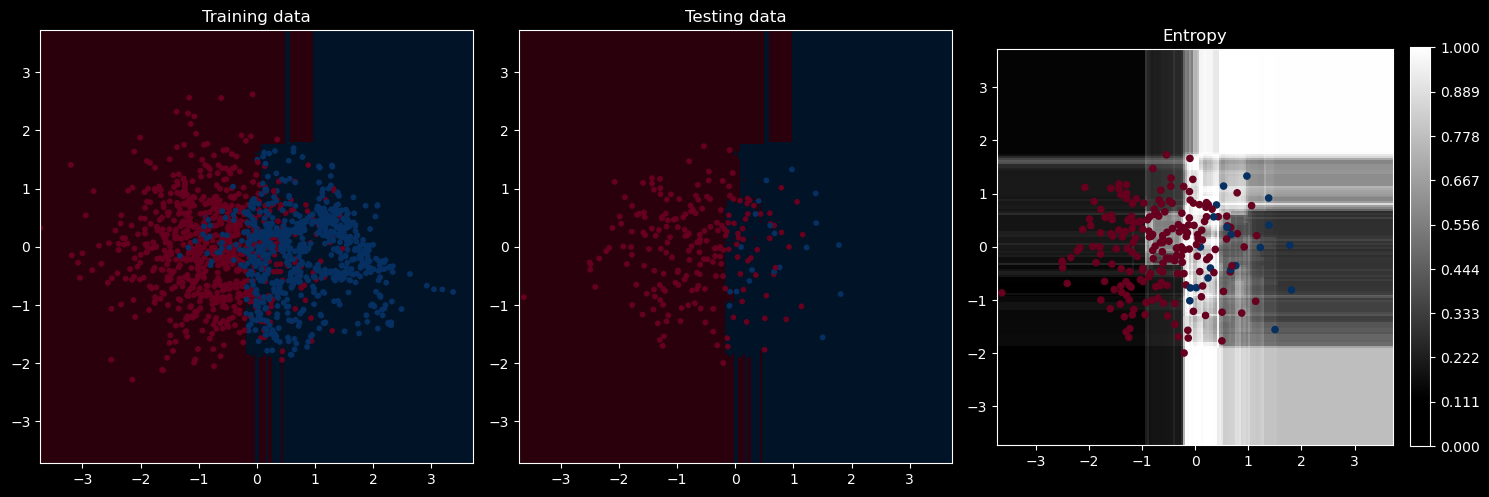




GradientBoostingClassifier(max_leaf_nodes=3, n_estimators=10)
Original dataset:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       200
           1       1.00      0.25      0.40        20

    accuracy                           0.93       220
   macro avg       0.97      0.62      0.68       220
weighted avg       0.94      0.93      0.91       220



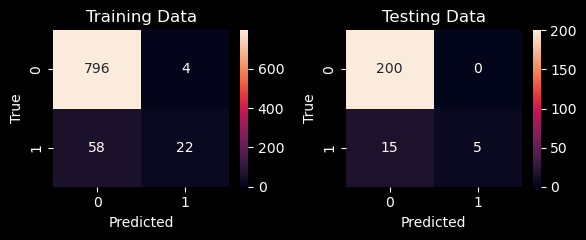

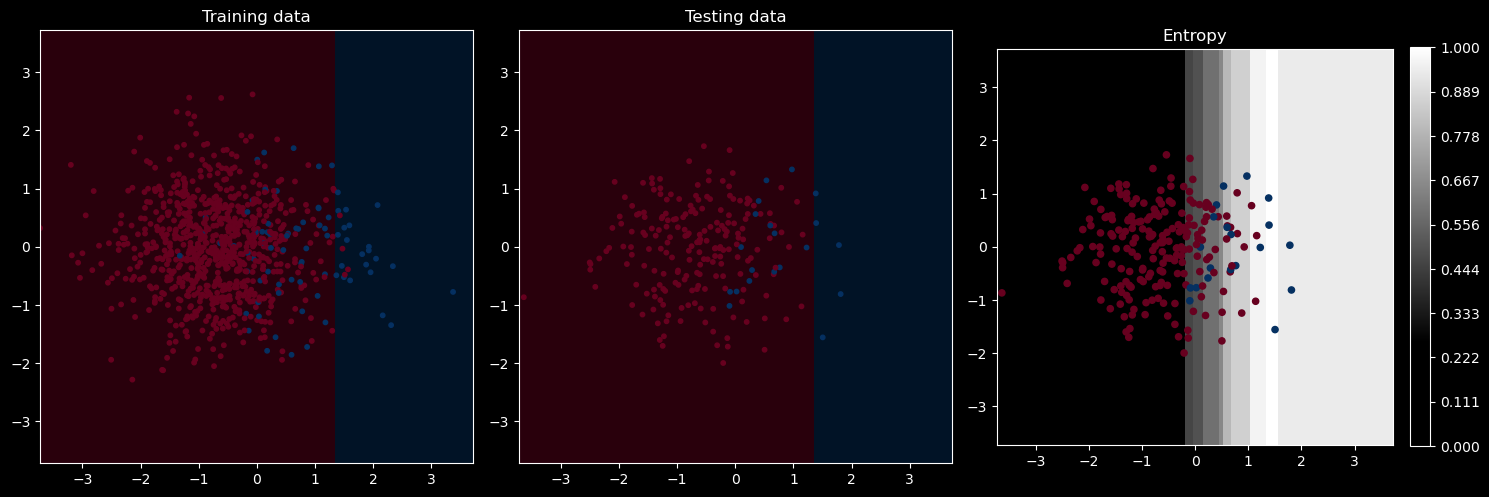

Resampled dataset:
              precision    recall  f1-score   support

           0       1.00      0.73      0.85       200
           1       0.27      1.00      0.43        20

    accuracy                           0.76       220
   macro avg       0.64      0.87      0.64       220
weighted avg       0.93      0.76      0.81       220



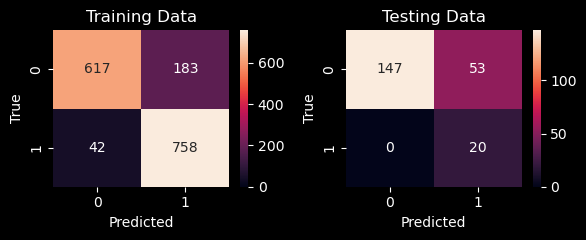

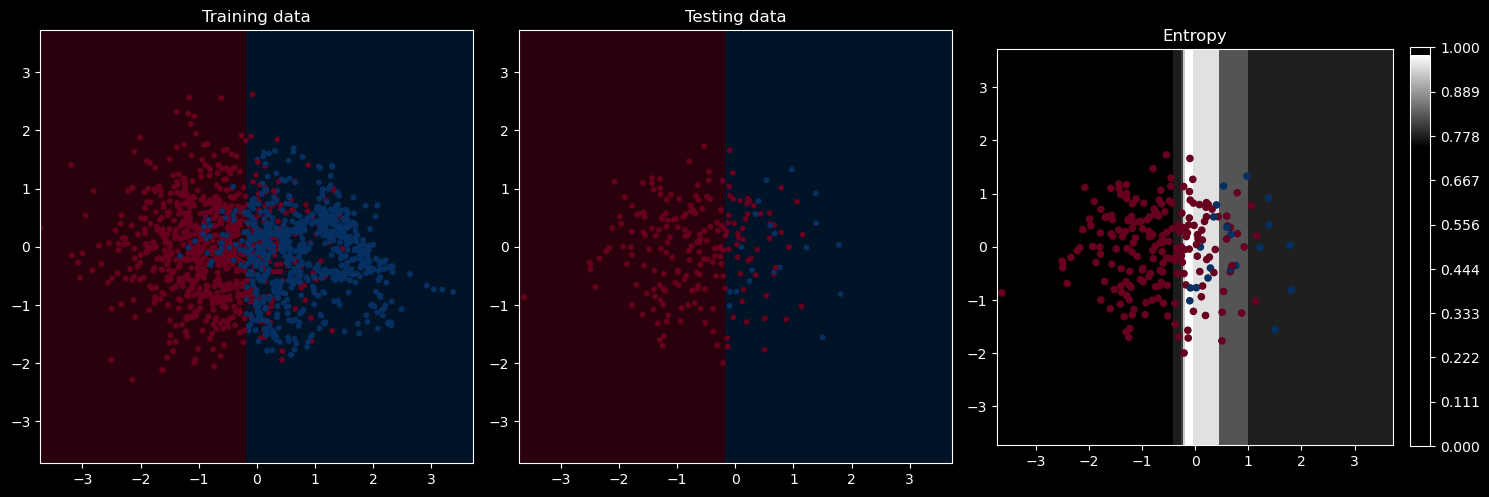




GradientBoostingClassifier(max_leaf_nodes=10, n_estimators=10)
Original dataset:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       200
           1       0.80      0.20      0.32        20

    accuracy                           0.92       220
   macro avg       0.86      0.60      0.64       220
weighted avg       0.91      0.92      0.90       220



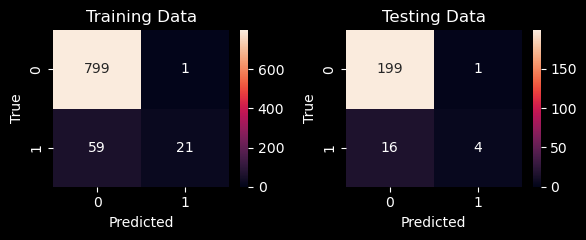

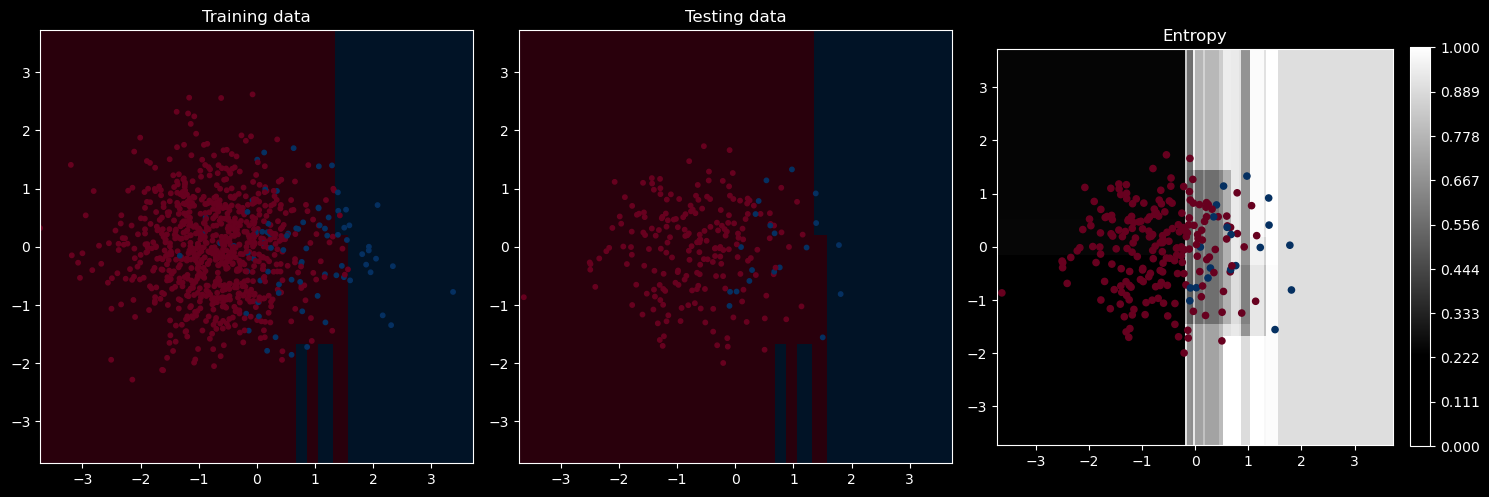

Resampled dataset:
              precision    recall  f1-score   support

           0       1.00      0.74      0.85       200
           1       0.28      1.00      0.44        20

    accuracy                           0.77       220
   macro avg       0.64      0.87      0.65       220
weighted avg       0.93      0.77      0.82       220



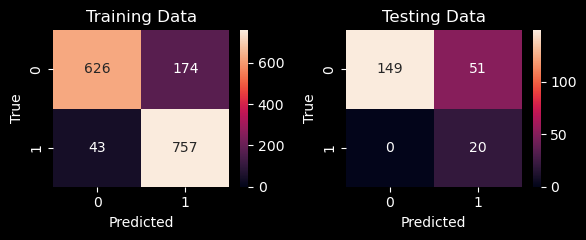

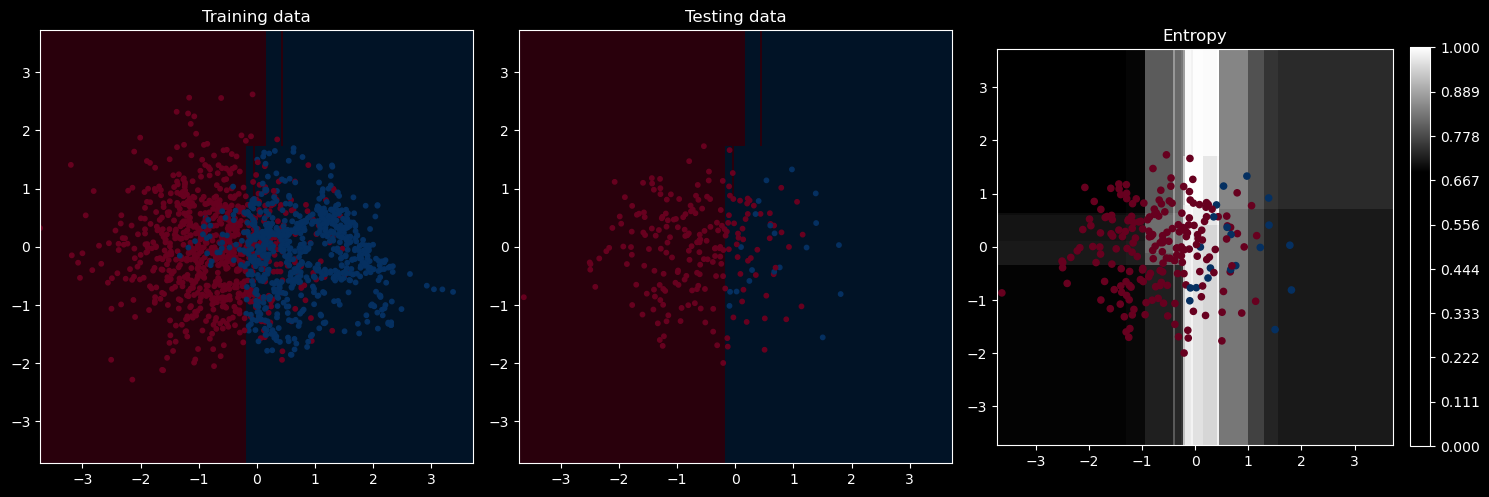




GradientBoostingClassifier(max_leaf_nodes=3)
Original dataset:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       200
           1       0.54      0.35      0.42        20

    accuracy                           0.91       220
   macro avg       0.74      0.66      0.69       220
weighted avg       0.90      0.91      0.91       220



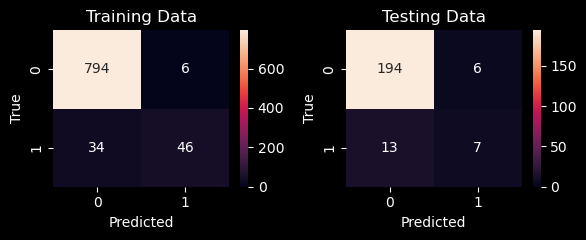

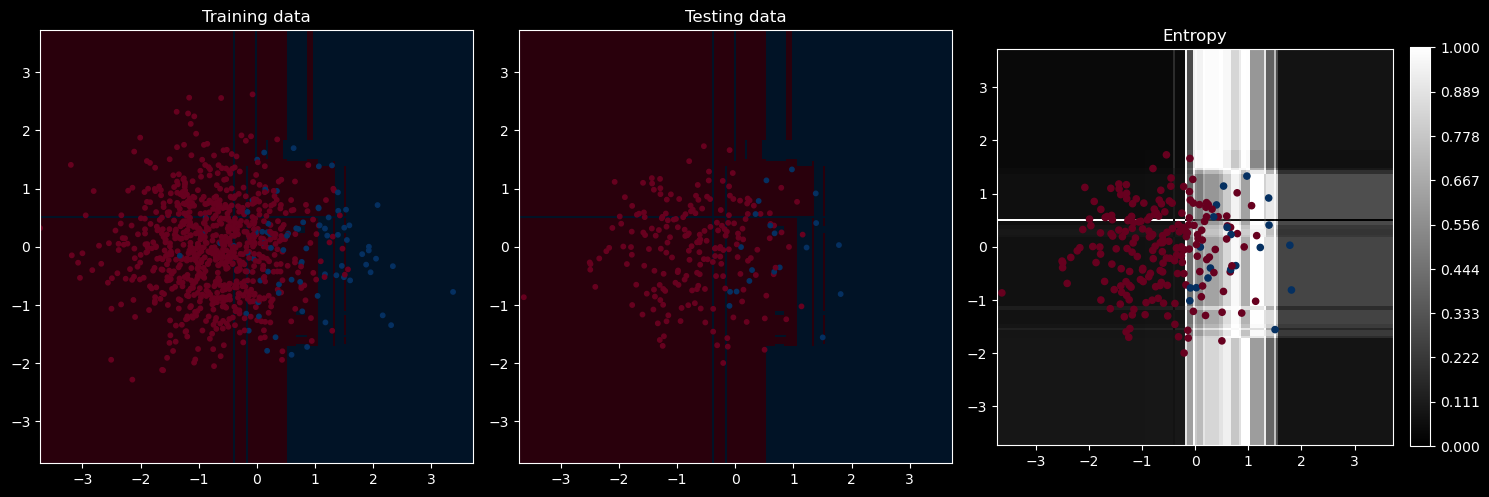

Resampled dataset:
              precision    recall  f1-score   support

           0       1.00      0.76      0.86       200
           1       0.29      1.00      0.45        20

    accuracy                           0.78       220
   macro avg       0.64      0.88      0.65       220
weighted avg       0.94      0.78      0.82       220



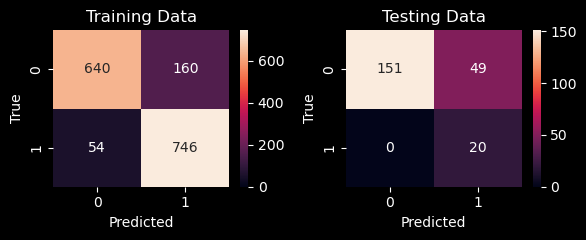

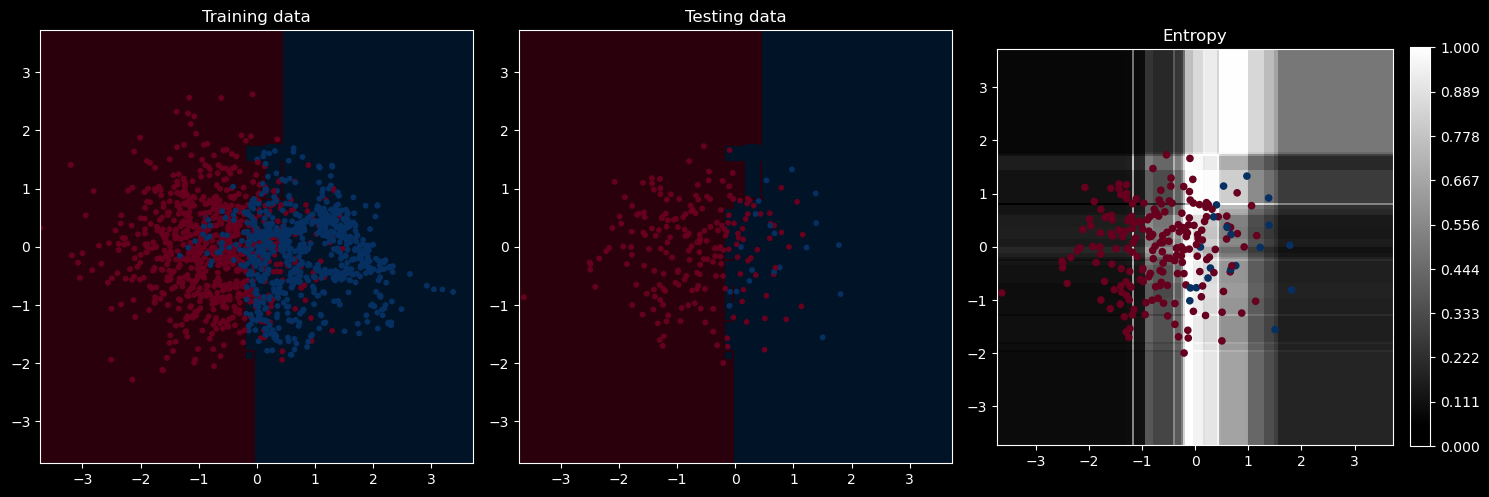




GradientBoostingClassifier(max_leaf_nodes=10)
Original dataset:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       200
           1       0.54      0.35      0.42        20

    accuracy                           0.91       220
   macro avg       0.74      0.66      0.69       220
weighted avg       0.90      0.91      0.91       220



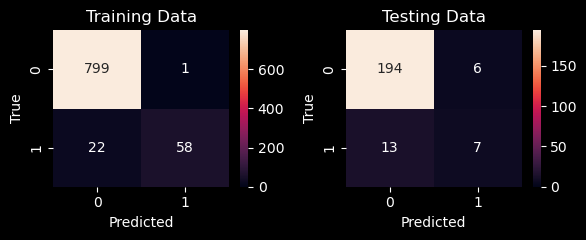

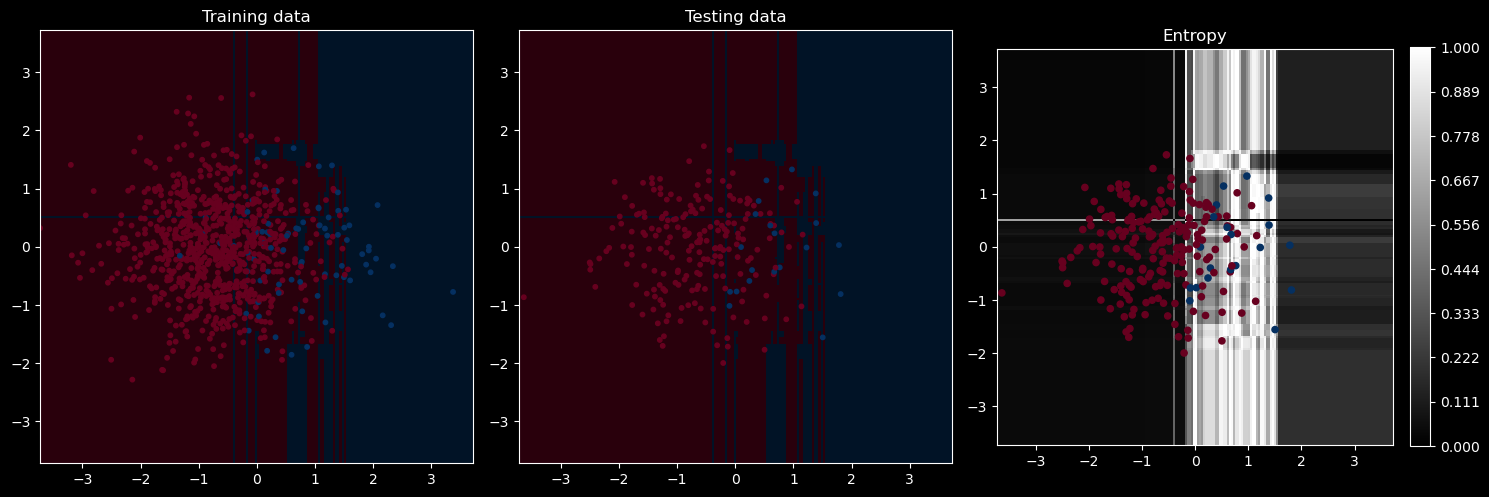

Resampled dataset:


              precision    recall  f1-score   support

           0       0.99      0.75      0.85       200
           1       0.28      0.95      0.43        20

    accuracy                           0.77       220
   macro avg       0.63      0.85      0.64       220
weighted avg       0.93      0.77      0.82       220



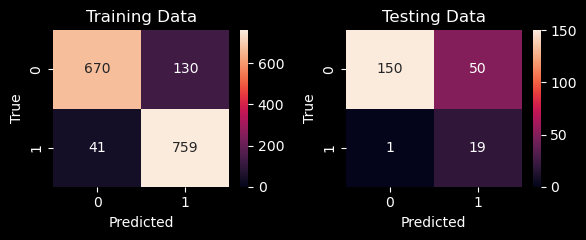

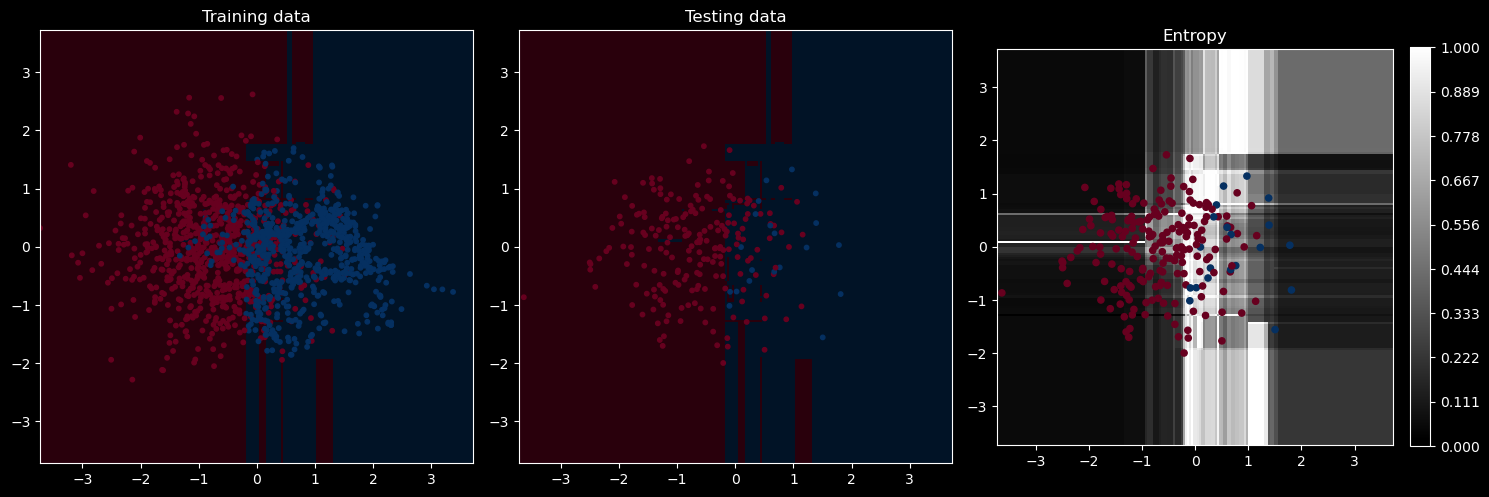

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

for m in models:
    print(m)

    ##########
    
    print("Original dataset:")
    m.fit(X_train, y_train)
    y_train_pred = m.predict(X_train).astype(int)
    y_test_pred = m.predict(X_test).astype(int)
    
    print(classification_report(y_test, y_test_pred))
    
    conf_matrix_train = confusion_matrix(y_train, y_train_pred).astype(int)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred).astype(int)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))
    
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")
    
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")
    
    plt.tight_layout()
    plt.show()

    B, S = visualize_regions(m, MAX, 200)
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
    extent = [-MAX,MAX,-MAX,MAX]
    
    cmap = "RdBu"
    axes[0].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap);
    axes[0].set_aspect('equal')
    axes[0].set_title('Training data');
    
    axes[1].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap);
    axes[1].set_aspect('equal')
    axes[1].set_title('Testing data');
    
    im = axes[2].imshow(S, interpolation='none', extent=extent,cmap='gray')
    axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap);
    axes[2].set_aspect('equal')
    axes[2].set_title('Entropy')
    cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.set_ticks(np.linspace(0, math.log(y.max()+1,2), 10))

    plt.tight_layout()
    plt.show()

    ############
    
    print("Resampled dataset:")
    m.fit(X_train_res, y_train_res)
    y_train_res_pred = m.predict(X_train_res).astype(int)
    y_test_res_pred = m.predict(X_test).astype(int)
    
    print(classification_report(y_test, y_test_res_pred))
    
    conf_matrix_train_res = confusion_matrix(y_train_res, y_train_res_pred).astype(int)
    conf_matrix_test_res = confusion_matrix(y_test, y_test_res_pred).astype(int)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))
    
    sns.heatmap(conf_matrix_train_res, annot=True, vmin=0, fmt='d', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")
    
    sns.heatmap(conf_matrix_test_res, annot=True, vmin=0, fmt='d', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")
    
    plt.tight_layout()
    plt.show()

    B, S = visualize_regions(m, MAX, 200)
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
    extent = [-MAX,MAX,-MAX,MAX]
    
    cmap = "RdBu"
    axes[0].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[0].scatter(X_train_res[:,0], X_train_res[:,1], c=y_train_res, s=10, cmap=cmap);
    axes[0].set_aspect('equal')
    axes[0].set_title('Training data');
    
    axes[1].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap);
    axes[1].set_aspect('equal')
    axes[1].set_title('Testing data');
    
    im = axes[2].imshow(S, interpolation='none', extent=extent,cmap='gray')
    axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap);
    axes[2].set_aspect('equal')
    axes[2].set_title('Entropy')
    cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.set_ticks(np.linspace(0, math.log(y.max()+1,2), 10))

    plt.tight_layout()
    plt.show()

    print()
    print()
    print()
# end

## 5. Review

- **SMOTE synthesizes rather than duplicates**, placing new minority points on segments between a
  real point and one of its $k$ nearest minority neighbours:
  $\mathbf{x}_{\text{new}} = \mathbf{x}_i + \lambda(\mathbf{x}_{zi} - \mathbf{x}_i)$.
- **Every synthetic point is a convex combination of two real ones**, so SMOTE densifies the region
  the minority class already occupies and can never extend beyond its convex hull.
- **`k_neighbors` is the key setting.** Too small and it degenerates toward duplication; too large
  and interpolated points can land inside majority territory as mislabeled data. It must be less
  than the minority sample count.
- **It assumes a meaningful feature space** — scale first, and use `SMOTENC` when categorical
  features are present.
- **Training split only**, as with every resampling method.